In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('global-temperatures.csv', comment='#', header=None, sep=' ')
data.columns = ['year', 'temp']

In [3]:
# calculating the fit
x = data['year'].to_numpy()
y = data['temp'].to_numpy()

#creating the design matrix X
X = np.c_[np.ones(len(x)), x]

#calculatint predicted beta
beta = np.linalg.inv(X.T @ X ) @ X.T @ y 
#calculating the predicted y line
y_pred = beta[0] + beta[1] * x

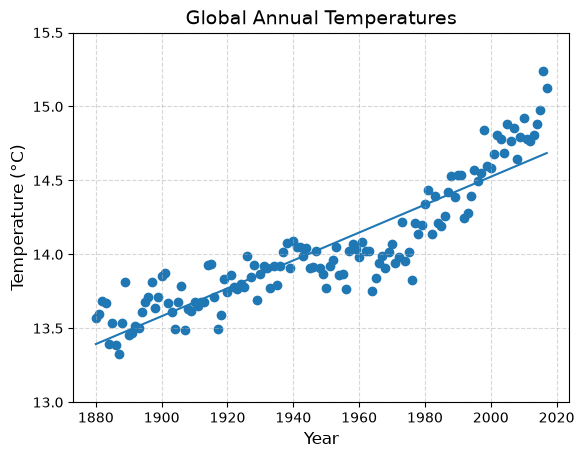

In [14]:
# plotting
plt.scatter(data['year'], data['temp'])
plt.plot(data['year'], y_pred)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.ylim(13, 15.5)
plt.title('Global Annual Temperatures', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

$R^2$ is a statistic metric without dimension that mesures the guality of the adjutement.  
If $R^2 = 1$ the adjustement is perfect  
If $R^2 < 0$ the adjustement is worse than the mean value  

$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_{i=1}^N(y_i-\hat{y}_i)^2}{\sum_{i=1}^N(y_i-\bar{y}_i)^2}$$

In [10]:
SSres = np.sum( (y - y_pred)**2 )
SStot = np.sum( (y - np.mean(y))**2 )
R2 = 1 - (SSres/SStot)
print(f'R2 = {R2:.3f}')

R2 = 0.815


The estimator $\hat{\beta}_1$ corresponds to the slope of the regression line

The residual is given by : $\epsilon_i = y_i - ( \beta_0 + \beta_1x_1)$

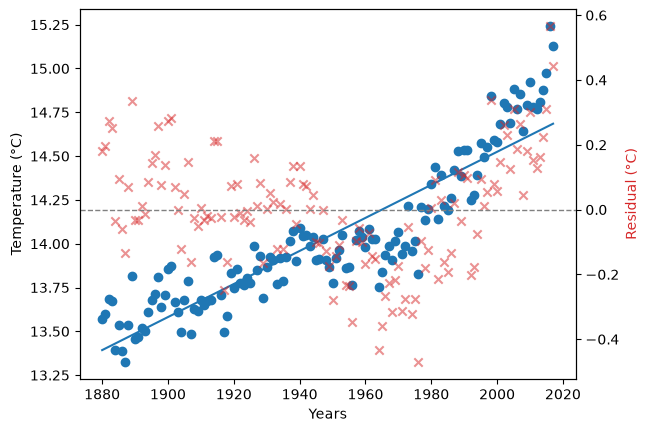

In [ ]:
res = y - ( beta[0] + beta[1] * x)

fig, ax1 = plt.subplots()

ax1.set_xlabel('Years')
ax1.set_ylabel('Temperature (°C)')
ax1.scatter(data['year'], data['temp'])
plt.plot(data['year'], y_pred)
ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('Residuals (°C)', color=color)
ax2.scatter(data['year'], res, color= color, alpha=0.5, marker="x")
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)